This tutorial covers best practices and example code for creating high-quality figures directly in Python. The guidelines are based on personal experience — think of them as a set of *golden rules* that have proven their worth over time. Following them from the start will save you a lot of reformatting work later.

::: {.callout-tip}
## Why learn this?
A week-long simulation is judged, in the end, by its **figures** — they are how your result reaches a reader, and often the only part a reviewer studies closely. A little structure up front saves hours of reformatting later.

- **Imagine you need** to change the font in all 30 figures of a paper — with a *stylesheet* that's one line, not 30 edits.
- **Imagine you need** to show where two million data points actually concentrate — a *density* plot does it honestly where a scatter just smears.
:::

## Guidelines for scientific figures

Before diving into code, it is worth establishing a few ground rules for what makes a good scientific figure. Getting these right from the start saves significant rework later.

- **General plotting style**
    - Consistent style — colour scheme, axis labels, line widths, …
    - Typeface and font size
        - LaTeX rendering (optional, for a perfect match).
        - Match the document by matching **font size**, **figure size**, and (optionally) **typeface**. The recommended figure and font sizes are usually in the journal's *author guidelines*.
        - If created this way, include the figure **without scaling** in LaTeX — use `scale=1` instead of the common `width=\textwidth`.
    - Figure quality and resolution
        - `.pdf` — line plots and small plots (scalable vector graphics).
        - `.png` / `.jpeg` — colour maps / contour plots (when PDF is impractical, and to avoid silent rescaling).
        - Sufficient resolution (~1000 dpi, or at least the journal guideline).
    - Labels and units
        - Consistent use; units set **non-italic** (upright).
        - Typical formatting of a quantity $T$ in kelvin:
            - $T$ / K — recommended by the [SI guidelines](https://physics.nist.gov/cuu/pdf/sp811.pdf)
            - $T$ in K
            - $T$ (K)
            - $T$ [K]
    - Data visualization
        - *Unambiguous* data representation (e.g. scatter vs. hexbin — see below).
        - A high level of self-explanation — readers often skim a paper looking only at the figures.


## Defining a consistent plotting style

A key aspect of high-quality figures is a **consistent** design across all of them: font size, typeface, text rendering, colour scheme, axis design, and so on. Below we build up from the approach most beginners reach for to the one worth adopting — Matplotlib **stylesheets**.

Our target style: a colour-blind-friendly colour cycle (the *tableau 10-blind* palette) paired with a set of line styles ([why colour-blind-friendly?](https://www.ctao.org/wp-content/uploads/ColourBlindFriendlyPractices_v2_032025.pdf)).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

tableau10blind = [
    "#006BA4", "#FF800E", "#ABABAB", "#595959", "#5F9ED1",
    "#C85200", "#898989", "#A2C8EC", "#FFBC79", "#CFCFCF",
]
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--"]

### Approach 1 — style inside each command (beginner)

The most intuitive approach: set every option directly in the plotting calls.

| Pros | Cons |
|---|---|
| Intuitive | Tedious — repeat it for every axis and figure |
| Simple to understand | Inefficient; clutters the code |


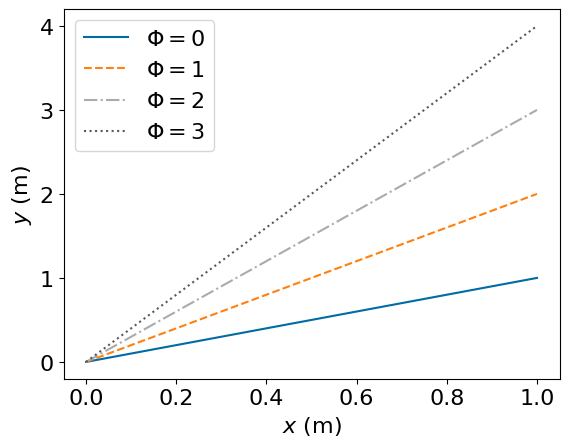

In [2]:
fig, ax = plt.subplots()
for i in range(4):
    ax.plot([0, 1], [0, i + 1], color=tableau10blind[i],
            linestyle=linestyles[i])
ax.set_xlabel("$x$ (m)", fontsize=16)
ax.set_ylabel("$y$ (m)", fontsize=16)
ax.tick_params(labelsize=16)
ax.legend([f"$\\Phi={i}$" for i in range(4)], fontsize=16)
plt.show()

### Approach 2 — Matplotlib `rcParams` (intermediate)

[`rcParams`](https://matplotlib.org/stable/users/explain/customizing.html) let you set styles **once**; they then apply to every plot below the definition.

| Pros | Cons |
|---|---|
| Central definition, more efficient | Still lives in each script |
| No per-command repetition | Leads to code duplication across files |


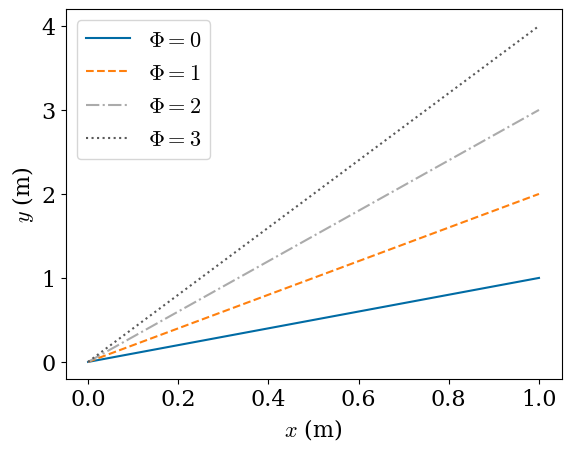

In [3]:
plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer-Modern math without a LaTeX install
    "axes.prop_cycle": mpl.cycler(color=tableau10blind, linestyle=linestyles),
})

fig, ax = plt.subplots()
for i in range(4):
    ax.plot([0, 1], [0, i + 1])
ax.set_xlabel("$x$ (m)")
ax.set_ylabel("$y$ (m)")
ax.legend([f"$\\Phi={i}$" for i in range(4)])
plt.show()
plt.rcdefaults()   # reset for the next section

### Approach 3 — Matplotlib stylesheets (recommended)

The gold standard is a [stylesheet](https://matplotlib.org/stable/users/explain/customizing.html) — a small `.mplstyle` file holding your defaults.

**Pros:** central definition, easy reuse across projects, highly flexible, and very clean code — with essentially no downside.

A stylesheet is a plain-text list of `key : value` settings. A good *starting* style (save it as `mystyle.mplstyle`):

```ini
figure.figsize   : 6.0, 4.0     # inches
figure.dpi       : 120          # on-screen scaling
savefig.dpi      : 500          # dpi when saving raster output
xtick.direction  : in
ytick.direction  : in
legend.frameon   : False
font.family      : serif
mathtext.fontset : cm
font.size        : 14
image.cmap       : turbo
# colour-blind-friendly colour + line-style cycle
axes.prop_cycle  : (cycler('color', ['006BA4','FF800E','ABABAB','595959','5F9ED1','C85200','898989','A2C8EC','FFBC79','CFCFCF']) + cycler('linestyle', ['-','--','-.',':','-','--','-.',':','-','--']))
```

Apply it with `plt.style.use('mystyle.mplstyle')`. The three files used in this course — `mystyle` (base), `mcgill-colors`, and `PROCI` (journal, LaTeX) — are provided in the `plotting-styles/` folder next to this notebook. Below we load the base style from a temporary file so the example is self-contained.

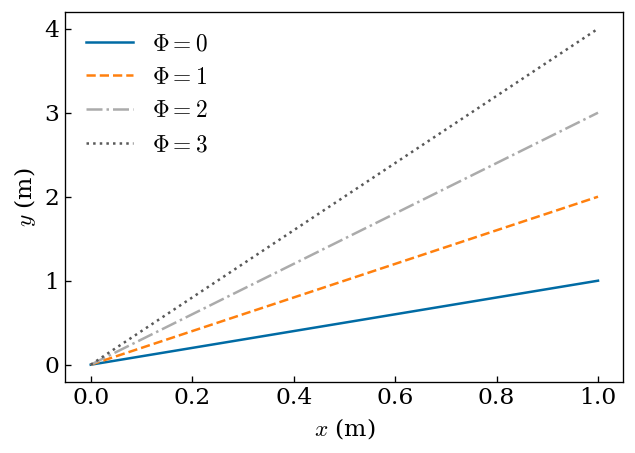

In [4]:
import tempfile, pathlib

MYSTYLE = '''
figure.figsize   : 6.0, 4.0
figure.dpi       : 120
savefig.dpi      : 500
xtick.direction  : in
ytick.direction  : in
legend.frameon   : False
font.family      : serif
mathtext.fontset : cm
font.size        : 14
image.cmap       : turbo
axes.prop_cycle  : (cycler('color', ['006BA4','FF800E','ABABAB','595959','5F9ED1','C85200','898989','A2C8EC','FFBC79','CFCFCF']) + cycler('linestyle', ['-','--','-.',':','-','--','-.',':','-','--']))
'''

style_dir = pathlib.Path(tempfile.mkdtemp())
(style_dir / "mystyle.mplstyle").write_text(MYSTYLE)

plt.rcdefaults()
plt.style.use(str(style_dir / "mystyle.mplstyle"))

fig, ax = plt.subplots()
for i in range(4):
    ax.plot([0, 1], [0, i + 1])
ax.set_xlabel("$x$ (m)")
ax.set_ylabel("$y$ (m)")
ax.legend([f"$\\Phi={i}$" for i in range(4)])
plt.show()

#### Make styles globally available
Place your `.mplstyle` files in Matplotlib's config directory and they become available in *every* script — no path needed, just `plt.style.use('mystyle')`.

In [5]:
print("put your styles here:", mpl.get_configdir() + "/stylelib")
print("some built-in styles:", plt.style.available[:8])

put your styles here: /root/.config/matplotlib/stylelib
some built-in styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast']


#### Combine styles, and apply one locally
Styles compose: a **base** style plus a **journal/medium-specific** one (font and figure size for a paper vs. a poster). You can also apply a style to a *single* figure with a `with` context, leaving everything else untouched.

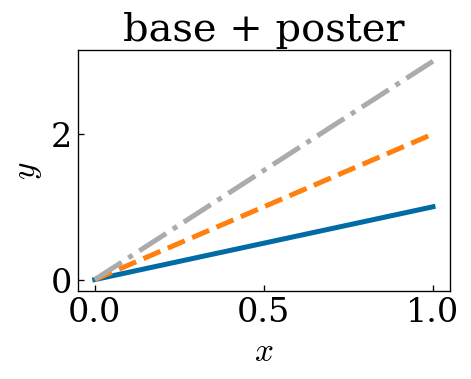

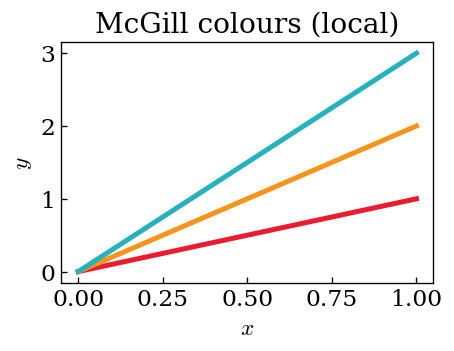

In [6]:
POSTER = 'font.size: 20\nlines.linewidth: 3\n'
MCGILL = ("axes.prop_cycle: cycler('color', "
          "['ED1B2F','F7941D','27B0BE','305534','024F6D','B2D235'])\n")
(style_dir / "poster.mplstyle").write_text(POSTER)
(style_dir / "mcgill.mplstyle").write_text(MCGILL)

def demo(ax):
    for i in range(3):
        ax.plot([0, 1], [0, i + 1])
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")

# base + poster overrides, combined in a list (later wins)
plt.rcdefaults()
plt.style.use([str(style_dir / "mystyle.mplstyle"),
               str(style_dir / "poster.mplstyle")])
fig, ax = plt.subplots(figsize=(4, 2.6)); demo(ax)
ax.set_title("base + poster"); plt.show()

# McGill colours for THIS figure only
with plt.style.context([str(style_dir / "mystyle.mplstyle"),
                        str(style_dir / "mcgill.mplstyle")]):
    fig, ax = plt.subplots(figsize=(4, 2.6)); demo(ax)
    ax.set_title("McGill colours (local)"); plt.show()
plt.rcdefaults()

#### Make it fail-safe
If a style might not be installed on every machine, guard it so your script still runs:

```python
try:
    plt.style.use(['mystyle', 'PROCI'])
except OSError:
    print("Matplotlib styles not found — using defaults")
```

#### For a journal: true LaTeX rendering
For a *perfect* typeface match, a journal style enables LaTeX typesetting. This needs a working LaTeX toolchain (and the right fonts/packages), so the `PROCI.mplstyle` below is shown for reference and **not executed** here:

```ini
font.family         : serif
font.serif          : Times New Roman
text.usetex         : true
font.size           : 7
text.latex.preamble : \usepackage{amsmath}\usepackage{times}
lines.linewidth     : 1.0
savefig.bbox        : tight
```

**Imagine you need** to relabel the temperature axis across 15 figures from `T (K)` to `T / K`. Hand-typing LaTeX 15 times invites typos — a *label dictionary* keeps one source of truth. This is super easy in Python using a `dict` with `.get()` fallbacks.

## Labels and limits

Consistent axis labels and limits are a hallmark of high-quality figures. A clean, dictionary-based approach makes defining and reusing them across figures reliable.

### Always work with an explicit axis
Create the figure and axis explicitly and pass the **axis** into your plotting helpers, rather than relying on Matplotlib's implicit *current axis*. Instead of `plt.plot(...)`, use `fig, ax = plt.subplots()` then `ax.plot(...)`. This makes helper functions reusable and trivially extensible to multi-panel figures.

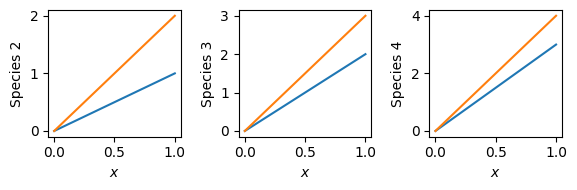

In [7]:
def lineplot(ax, i):
    ax.plot([0, 1], [0, i])
    ax.set_xlabel("$x$")
    ax.set_ylabel(f"Species {i}")
    return ax

fig, axs = plt.subplots(ncols=3, figsize=(6, 2))
for i, ax in enumerate(axs):
    lineplot(ax, i + 1)
    lineplot(ax, i + 2)
fig.tight_layout()
plt.show()

### Dictionaries for labels and limits
Map each variable name (as used to access your data, e.g. a column of a `DataFrame`) to its label string and axis limits. The dictionary `.get` method gives a **fail-safe default** when a key is missing.

In [8]:
var_label = {
    "T":  "$T$ (K)",
    "CO": "$Y_{\\mathrm{CO}}$ (-)",
    "OH": "$Y_{\\mathrm{OH}}$ (-)",
}
lims = {
    "T":  (300, 2500),
    "CO": (0, 0.05),
    "OH": (0, 0.007),
}

print("found    :", var_label.get("T", "T"))
print("fallback :", var_label.get("CO2", "CO2"))   # key missing -> name

found    : $T$ (K)
fallback : CO2


### Generate labels in a chosen unit style
Store each quantity as its LaTeX symbol **and** unit, then assemble the label in whichever convention you want — matching the four styles from the guidelines above (`T / K`, `T in K`, `T (K)`, `T [K]`).

In [9]:
latex_label_unit = {
    "t": {"latex_string": "$t$", "unit": "s"},
    "z": {"latex_string": "$z$", "unit": "m"},
    "T": {"latex_string": "$T$", "unit": "K"},
}

def define_label_dict(d, style=0):
    """style: 0 -> 'q / u', 1 -> 'q in u', 2 -> 'q (u)', 3 -> 'q [u]'."""
    sep = {0: " / {}", 1: " in {}", 2: " ({})", 3: " [{}]"}[style]
    return {k: v["latex_string"] + sep.format(v["unit"])
            for k, v in d.items()}

for s in range(4):
    print(s, define_label_dict(latex_label_unit, style=s))

0 {'t': '$t$ / s', 'z': '$z$ / m', 'T': '$T$ / K'}
1 {'t': '$t$ in s', 'z': '$z$ in m', 'T': '$T$ in K'}
2 {'t': '$t$ (s)', 'z': '$z$ (m)', 'T': '$T$ (K)'}
3 {'t': '$t$ [s]', 'z': '$z$ [m]', 'T': '$T$ [K]'}


### Helpers to set labels and limits on any axis
Small, reusable functions that look everything up from the dictionaries — with graceful fallbacks.

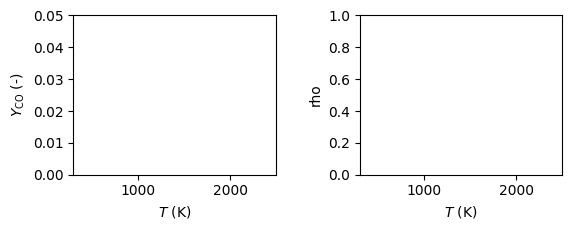

note: 'rho' had no dictionary entry, so its axis label is just the name


In [10]:
def set_labels(ax, xv, yv, label_dict):
    ax.set_xlabel(label_dict.get(xv, xv))
    ax.set_ylabel(label_dict.get(yv, yv))

def set_limits(ax, xv, yv, lims):
    if lims.get(xv):
        ax.set_xlim(lims[xv])
    if lims.get(yv):
        ax.set_ylim(lims[yv])

def set_label_and_limits(ax, xv, yv, label_dict={}, lims={}):
    set_labels(ax, xv, yv, label_dict)
    set_limits(ax, xv, yv, lims)

fig, axs = plt.subplots(ncols=2, figsize=(6, 2.4))
for yv, ax in zip(["CO", "rho"], axs):          # 'rho' is missing on purpose
    set_label_and_limits(ax, "T", yv, label_dict=var_label, lims=lims)
fig.tight_layout()
plt.show()
print("note: 'rho' had no dictionary entry, so its axis label is just the name")

## Figure size and file format

Draw the figure at the width it will occupy (one column ≈ 3.5 in) and place it in LaTeX with `scale=1`. Save **line plots as `.pdf`** (vector, sharp at any zoom) and **colour maps / contour plots as `.png`** at high dpi (a vector version would be huge).

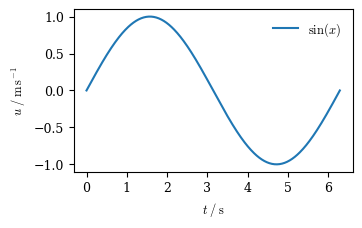

In [11]:
GOLDEN = (1 + 5 ** 0.5) / 2
x = np.linspace(0, 2 * np.pi, 400)

plt.rcdefaults()
plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm",
                     "font.size": 9})
fig, ax = plt.subplots(figsize=(3.5, 3.5 / GOLDEN))
ax.plot(x, np.sin(x), label=r"$\sin(x)$")
ax.set_xlabel(r"$t \; / \; \mathrm{s}$")
ax.set_ylabel(r"$u \; / \; \mathrm{m\,s^{-1}}$")
ax.legend(frameon=False)
fig.tight_layout(pad=0.3)
fig.savefig("lineplot.pdf")            # vector, for a line plot
plt.show()

**Imagine you need** to plot a $u'$–$v'$ cloud of two million points. A scatter plot turns into a solid black blob; you need to show *density*. This is super easy in Python using `hexbin`.

## Unambiguous data: scatter vs. hexbin
A scatter plot of many points *overplots* — dense regions saturate and hide the true distribution. For large samples a 2-D density (`hexbin`) is honest and readable.

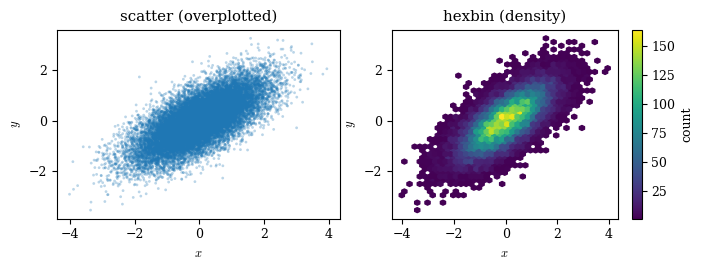

In [12]:
rng = np.random.default_rng(0)
n = 20_000
xd = rng.normal(0, 1, n)
yd = xd * 0.6 + rng.normal(0, 0.6, n)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7, 2.6))
a1.scatter(xd, yd, s=4, alpha=0.3, edgecolors="none")
a1.set_title("scatter (overplotted)")
hb = a2.hexbin(xd, yd, gridsize=40, cmap="viridis", mincnt=1)
a2.set_title("hexbin (density)")
fig.colorbar(hb, ax=a2, label="count")
for a in (a1, a2):
    a.set_xlabel(r"$x$"); a.set_ylabel(r"$y$")
fig.tight_layout(pad=0.4)
plt.show()

## Self-tests

**1. Stylesheet.** Write a two-line style string that sets `font.size` to 12 and puts the ticks *inside* the axes, save it to a temp file, apply it, and make any quick plot.

In [ ]:
#| code-fold: true
#| code-summary: "Show solution"
#| output: false
import tempfile, pathlib
s = 'font.size: 12\nxtick.direction: in\nytick.direction: in\n'
p = pathlib.Path(tempfile.mkdtemp()) / "t.mplstyle"
p.write_text(s)
plt.rcdefaults(); plt.style.use(str(p))
fig, ax = plt.subplots(figsize=(3, 2)); ax.plot([0, 1], [0, 1]); plt.show()
plt.rcdefaults()

**2. Label dictionary.** Using `var_label` above, write a helper `ylabel(ax, key)` that sets the y-label from the dictionary, falling back to the key if it is missing. Test it with `"OH"` and `"foo"`.

In [ ]:
#| code-fold: true
#| code-summary: "Show solution"
#| output: false
def ylabel(ax, key):
    ax.set_ylabel(var_label.get(key, key))

fig, ax = plt.subplots(figsize=(3, 2))
ylabel(ax, "OH"); print("OH  ->", ax.get_ylabel())
ylabel(ax, "foo"); print("foo ->", ax.get_ylabel())
plt.close(fig)

**3. Format choice.** You made (a) a convergence-history line plot and (b) a filled temperature contour. Which file format for each?

::: {.callout-tip collapse="true"}
## Solution
(a) **`.pdf`** — a few vector paths, sharp at any zoom, tiny file. (b) **`.png` at ~1000 dpi** — a filled contour is effectively an image; a vector version would contain a huge number of polygons, so a high-dpi raster is smaller and reliable.
:::

## Turbulence in practice: the energy spectrum

The canonical turbulence figure is the Kolmogorov inertial-range spectrum $E(k)=C\,\varepsilon^{2/3}k^{-5/3}$ on log--log axes, where a power law becomes a straight line — exactly the kind of plot the style above is built for.

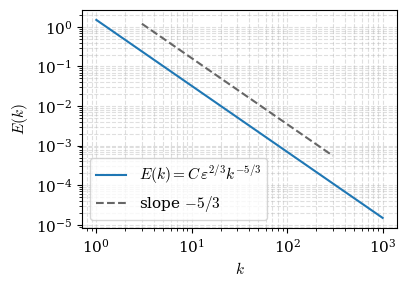

In [15]:
def energy_spectrum(k, C=1.5, eps=1.0):
    return C * eps ** (2 / 3) * k ** (-5 / 3)

k = np.logspace(0, 3, 200)
plt.rcdefaults()
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm',
                     'font.size': 11})
fig, ax = plt.subplots(figsize=(4.2, 3.0))
ax.loglog(k, energy_spectrum(k), label=r'$E(k)=C\,\varepsilon^{2/3}k^{-5/3}$')
ax.loglog([3, 300], 5 * energy_spectrum(np.array([3.0, 300.0])), '--',
          color='0.4', label=r'slope $-5/3$')
ax.set_xlabel(r'$k$'); ax.set_ylabel(r'$E(k)$')
ax.grid(True, which='both', ls='--', alpha=0.4); ax.legend()
fig.tight_layout(); plt.show()

**Self-test.** Overlay a second spectrum with ten times the dissipation ($\varepsilon = 10$) and label both. Which lies higher, and why?

In [ ]:
#| code-fold: true
#| code-summary: "Show solution"
#| output: false
fig, ax = plt.subplots(figsize=(4.2, 3.0))
for eps in (1.0, 10.0):
    ax.loglog(k, energy_spectrum(k, eps=eps), label=fr'$\varepsilon={eps:g}$')
ax.set_xlabel(r'$k$'); ax.set_ylabel(r'$E(k)$')
ax.grid(True, which='both', ls='--', alpha=0.4); ax.legend()
fig.tight_layout(); plt.show()
# E ~ eps^(2/3): more dissipation lifts the whole curve, so eps=10 sits above.